<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Métricas de Clasificación: Accuracy, Precision, Recall y F1 🎯
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Machine Learning
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 03
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Machine%20Learning/03%20-%20Metricas%20y%20Ajuste%20de%20Hiperparametros/00_Metricas_de_Clasificacion.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## Objetivos de Aprendizaje 🔎

Este cuaderno desarrolla la **Sección 1.9 (Evaluación de modelos)** del Capítulo 1, en sus subsecciones **1.9.1 *Accuracy***, **1.9.2 *Precision***, **1.9.3 *Recall*** y **1.9.4 *F1-Score***. Hasta ahora entrenamos modelos (regresión logística, árboles, bosques, redes) y los evaluamos casi siempre con un solo número: el *accuracy*. Aquí aprendemos **qué mide cada métrica, qué esconde y cuándo engaña**. Como siempre: **teoría formal, implementación desde cero y verificación contra `scikit-learn`** con `assert`.

Al terminar podrás:

1. **Construir** la matriz de confusión (VP, FP, FN, VN) y **derivar** de ella todas las métricas con sus definiciones formales.
2. **Demostrar** con números la **paradoja de la exactitud**: un modelo inútil puede tener 99 % de *accuracy* en clases desbalanceadas.
3. **Explicar** el compromiso (*trade-off*) entre *precision* y *recall* al mover el **umbral de decisión** y leerlo en una curva.
4. **Justificar** por qué el F1 es una media **armónica** (y no aritmética) y generalizarlo a $F_\beta$.
5. **Calcular** promedios *macro*, *micro* y *weighted* en problemas **multiclase** e interpretar sus diferencias.
6. **Elegir** la métrica (y el umbral) según el **costo de cada tipo de error**: fraude, diagnóstico médico, spam.
7. **Calcular desde cero** ROC-AUC y PR-AUC (métricas independientes del umbral) y saber cuándo cada una engaña.
8. **Reproducir** `classification_report` a mano y **verificar** que todas las implementaciones coinciden con `sklearn.metrics`.

> 📍 **Dónde estamos:** Módulo 03, cuaderno 1 de 3. Le siguen [Métricas de Regresión](01_Metricas_de_Regresion.ipynb) y [Validación Cruzada y GridSearch](02_Validacion_Cruzada_y_GridSearch.ipynb). Vienen de los modelos de [regresión logística (Módulo 01)](../01%20-%20Modelos%20Lineales%20Supervisados/02_Regresion_Logistica.ipynb) y [bosques aleatorios (Módulo 02)](../02%20-%20Arboles%20Bosques%20y%20Redes%20Neuronales/01_Random_Forests.ipynb), cuyos scores evaluaremos.

> 🔗 **Para no repetir:** el manejo práctico de estas métricas con `scikit-learn` (matriz de confusión gráfica, `classification_report`, curva ROC, índice de Youden) está en [Data Science Programming — Módulo 08 (cuaderno 03)](../../Data%20Science%20programming/08%20-%20Classification/03_Evaluacion_de_Modelos_y_Metricas_Clasificacion.ipynb) y en [Data Mining — Módulo 02 (cuaderno 04)](../../Data%20Mining/02%20-%20Clasificacion%20y%20Regresion/04_Metricas_de_Evaluacion_en_Clasificacion_y_Regresion.ipynb). Aquí profundizamos en **definiciones formales, implementación propia, propiedades y trampas de interpretación**.

---
## Recursos Recomendados 📚

### 📖 Libros de Referencia:
- *Hands-On Machine Learning with Scikit-Learn and PyTorch* — **Aurélien Géron** (O'Reilly, 2025). Cap. 3 (*Classification*), sección *Performance Measures*: *Measuring Accuracy Using Cross-Validation*, *Confusion Matrices*, *Precision and Recall*, *The Precision/Recall Trade-off* y *The ROC Curve* (disponible en `Machine Learning/Libros/`).
- *Python Machine Learning* — **Sebastian Raschka** (Packt, 2015). Cap. 6 (*Learning Best Practices for Model Evaluation and Hyperparameter Tuning*): *Looking at different performance evaluation metrics*, con *Reading a confusion matrix* y *Optimizing the precision and recall of a classification model* (disponible en `Machine Learning/Libros/`).
- *The Elements of Statistical Learning* — **Hastie, Tibshirani & Friedman**. Cap. 9 (sensibilidad, especificidad y curvas ROC en clasificación) y Cap. 7 (evaluación de modelos). *(Capítulos citados de memoria: verifícalos en tu edición.)*
- Powers, D. M. W. (2011), *Evaluation: from precision, recall and F-measure to ROC, informedness, markedness and correlation*, **Journal of Machine Learning Technologies** 2(1): 37–63 *(citado de memoria, verificar)*.
- Davis, J. & Goadrich, M. (2006), *The relationship between Precision-Recall and ROC curves*, **ICML 2006** *(citado de memoria, verificar)*.
- van Rijsbergen, C. J. (1979), *Information Retrieval*, 2.ª ed., Butterworths: origen de la medida $F$ *(citado de memoria, verificar)*.

### 🌐 Documentación y Recursos Online:
- [scikit-learn: Metrics and scoring — classification metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics)
- [scikit-learn: `confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) · [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)
- [scikit-learn: Precision, recall and F-measures](https://scikit-learn.org/stable/modules/model_evaluation.html#precision-recall-f-measure-metrics)
- [scikit-learn: Receiver operating characteristic (ROC)](https://scikit-learn.org/stable/modules/model_evaluation.html#receiver-operating-characteristic-roc)

---
## 1. La Matriz de Confusión: la Materia Prima de Todo 🧩

Un clasificador binario produce, para cada ejemplo, una predicción $\hat y \in \{0, 1\}$ que se compara con la etiqueta real $y$. Por convención llamamos **positiva** (1) a la clase «de interés» (enfermo, fraude, spam) y **negativa** (0) a la otra. Hay **cuatro resultados posibles**:

| | **Predicho positivo** ($\hat y = 1$) | **Predicho negativo** ($\hat y = 0$) |
|---|---|---|
| **Real positivo** ($y = 1$) | **VP** — verdadero positivo (*TP*) | **FN** — falso negativo (*FN*), «error tipo II» |
| **Real negativo** ($y = 0$) | **FP** — falso positivo (*FP*), «error tipo I» | **VN** — verdadero negativo (*TN*) |

Con $n = VP + FP + FN + VN$, **todas** las métricas de este cuaderno son funciones de esos cuatro conteos. Las definiciones formales (con $P = VP + FN$ los positivos reales y $N = FP + VN$ los negativos reales):

| Métrica | Fórmula | Pregunta que responde |
|---|---|---|
| **Accuracy** (exactitud) | $\dfrac{VP + VN}{n}$ | ¿Qué fracción de **todas** las predicciones fue correcta? |
| **Precision** (precisión, VPP) | $\dfrac{VP}{VP + FP}$ | De lo que **predije positivo**, ¿cuánto lo era? |
| **Recall** (sensibilidad, TPR) | $\dfrac{VP}{VP + FN} = \dfrac{VP}{P}$ | De los **positivos reales**, ¿cuántos encontré? |
| **Especificidad** (TNR) | $\dfrac{VN}{VN + FP} = \dfrac{VN}{N}$ | De los **negativos reales**, ¿cuántos identifiqué bien? |
| **FPR** (falsa alarma) | $\dfrac{FP}{FP + VN} = 1 - \text{especificidad}$ | De los negativos reales, ¿cuántos alarmé por error? |
| **F1** | $\dfrac{2\,\text{Prec}\cdot\text{Rec}}{\text{Prec}+\text{Rec}} = \dfrac{2\,VP}{2\,VP + FP + FN}$ | Resumen armónico de precision y recall |

> ⚠️ **Convención de `scikit-learn`:** `confusion_matrix(y, y_pred)` devuelve `[[VN, FP], [FN, VP]]` con **filas = real** y **columnas = predicho**, es decir, el **orden inverso** de la tabla de arriba. Es la fuente número uno de confusiones al leer matrices ajenas; siempre verifica qué eje es cuál.

Empezamos implementando la matriz y las métricas **desde cero** (`NumPy` puro) y las **verificamos contra `sklearn.metrics`** sobre el conjunto *Breast Cancer Wisconsin* (clase positiva = tumor **maligno**, que en `scikit-learn` es la etiqueta 0, así que la invertimos para que «positivo = enfermo»).

In [ ]:
# ============================================================
# Configuracion inicial
# ============================================================
# !pip install -q numpy pandas matplotlib seaborn scikit-learn scipy

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import rankdata
from sklearn.datasets import load_breast_cancer, make_classification, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn import metrics as skm

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
print("Entorno listo.")

In [ ]:
# ============================================================
# 1. Matriz de confusion y metricas DESDE CERO, verificadas contra scikit-learn
# ============================================================
def dividir(a, b):
    """Division segura: si el denominador es 0 devuelve 0 (igual que zero_division=0 en sklearn)."""
    return a / b if b != 0 else 0.0

def conteos(y, y_pred):
    """Devuelve (VP, FP, FN, VN) para etiquetas binarias {0, 1}."""
    y, y_pred = np.asarray(y), np.asarray(y_pred)
    vp = int(np.sum((y == 1) & (y_pred == 1)))
    fp = int(np.sum((y == 0) & (y_pred == 1)))
    fn = int(np.sum((y == 1) & (y_pred == 0)))
    vn = int(np.sum((y == 0) & (y_pred == 0)))
    return vp, fp, fn, vn

def metricas_binarias(y, y_pred, beta=1.0):
    """Todas las metricas del cuaderno a partir de los cuatro conteos."""
    vp, fp, fn, vn = conteos(y, y_pred)
    prec, rec = dividir(vp, vp + fp), dividir(vp, vp + fn)
    esp = dividir(vn, vn + fp)
    b2 = beta ** 2
    fbeta = dividir((1 + b2) * vp, (1 + b2) * vp + b2 * fn + fp)            # forma en conteos (equivale a la armonica ponderada)
    mcc = dividir(vp * vn - fp * fn, np.sqrt(float(vp + fp) * (vp + fn) * (vn + fp) * (vn + fn)))
    return {"VP": vp, "FP": fp, "FN": fn, "VN": vn,
            "accuracy": (vp + vn) / (vp + fp + fn + vn), "precision": prec, "recall": rec,
            "especificidad": esp, "FPR": 1 - esp, "F1": dividir(2 * vp, 2 * vp + fp + fn), "Fbeta": fbeta,
            "accuracy_balanceada": (rec + esp) / 2, "MCC": mcc}

# --- Datos: positivo = tumor MALIGNO (en sklearn target==0), asi "positivo = enfermo" ---
bc = load_breast_cancer()
Xc, yc = bc.data, 1 - bc.target
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.3, stratify=yc, random_state=SEED)
modelo = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(Xc_tr, yc_tr)
y_hat = modelo.predict(Xc_te)

mio = metricas_binarias(yc_te, y_hat)
cm_sk = skm.confusion_matrix(yc_te, y_hat)                                   # sklearn: [[VN, FP], [FN, VP]]
assert np.array_equal(cm_sk, [[mio["VN"], mio["FP"]], [mio["FN"], mio["VP"]]])
assert np.isclose(mio["accuracy"], skm.accuracy_score(yc_te, y_hat))
assert np.isclose(mio["precision"], skm.precision_score(yc_te, y_hat))
assert np.isclose(mio["recall"], skm.recall_score(yc_te, y_hat))
assert np.isclose(mio["F1"], skm.f1_score(yc_te, y_hat))
assert np.isclose(mio["Fbeta"], skm.f1_score(yc_te, y_hat))                  # con beta = 1, Fbeta = F1
assert np.isclose(mio["especificidad"], skm.recall_score(yc_te, y_hat, pos_label=0))   # especificidad = recall de la clase negativa
assert np.isclose(mio["accuracy_balanceada"], skm.balanced_accuracy_score(yc_te, y_hat))
assert np.isclose(mio["MCC"], skm.matthews_corrcoef(yc_te, y_hat))
print("Todas las metricas propias coinciden con sklearn.metrics.\n")
display(pd.Series(mio).round(4).to_frame("valor").T)

fig, ax = plt.subplots(figsize=(5.6, 4.6))
sns.heatmap([[mio["VP"], mio["FN"]], [mio["FP"], mio["VN"]]], annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Pred. positivo", "Pred. negativo"], yticklabels=["Real positivo", "Real negativo"], annot_kws={"size": 16})
ax.set_title("Matriz de confusión (orden de la tabla: VP, FN / FP, VN)", fontweight="bold", fontsize=10)
plt.tight_layout()
plt.show()
print(f"Lectura: de {mio['VP'] + mio['FN']} tumores malignos reales detectamos {mio['VP']} (recall = {mio['recall']:.3f}); "
      f"de {mio['VP'] + mio['FP']} alarmas, {mio['VP']} eran reales (precision = {mio['precision']:.3f}).")

---
## 2. *Accuracy* y la Paradoja de la Exactitud ⚖️

### 2.1 Definición y la trampa

El ***accuracy*** es la fracción de aciertos, $\;\text{acc} = \dfrac{VP + VN}{n}$. Es intuitivo y **correcto cuando las clases están balanceadas y los dos errores cuestan lo mismo**. Su problema es que **pondera cada ejemplo por igual**, así que la **clase mayoritaria domina** el resultado.

Sea $\pi = P/n$ la **prevalencia** de la clase positiva. Un clasificador «trivial» que **siempre predice negativo** tiene $VP = FP = 0$, de modo que

$$\text{acc}_{\text{trivial}} = \frac{VN}{n} = 1 - \pi, \qquad \text{recall}_{\text{trivial}} = 0.$$

Si el fraude es el 1 % de las transacciones ($\pi = 0.01$), **un modelo que nunca detecta nada tiene 99 % de *accuracy***: es la **paradoja de la exactitud** (*accuracy paradox*). Un modelo real que detecta fraudes pero comete algunos errores de más puede tener *menos* accuracy y ser **muchísimo más útil**.

### 2.2 Alternativas robustas al desbalance

- **Accuracy balanceada** $= \dfrac{\text{recall} + \text{especificidad}}{2}$: promedia el desempeño **por clase**; el clasificador trivial obtiene 0.5, no 0.99.
- **Coeficiente de correlación de Matthews (MCC)** $= \dfrac{VP\cdot VN - FP\cdot FN}{\sqrt{(VP+FP)(VP+FN)(VN+FP)(VN+FN)}} \in [-1, 1]$: es la correlación entre $y$ y $\hat y$ y solo es alta si **las cuatro celdas** van bien (Powers, 2011, discute estas alternativas). El trivial obtiene 0.
- Las métricas **por clase** (*precision*, *recall*, F1) que veremos a continuación.

Lo demostramos numéricamente con un problema de fraude sintético ($\pi \approx 1\,\%$).

In [ ]:
# ============================================================
# 2. Paradoja de la exactitud: modelo trivial vs. modelo real (fraude, ~1 % de positivos)
# ============================================================
Xf, yf = make_classification(n_samples=30000, n_features=12, n_informative=5, n_redundant=2, n_clusters_per_class=2,
                             weights=[0.99, 0.01], class_sep=1.5, flip_y=0.0, random_state=SEED)
Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(Xf, yf, test_size=0.3, stratify=yf, random_state=SEED)
print(f"Prevalencia de fraude: {yf.mean():.2%}  ({yf_te.sum()} fraudes entre {len(yf_te)} transacciones de prueba)")

reg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(Xf_tr, yf_tr)
pred_real = reg.predict(Xf_te)                                 # modelo real (umbral 0.5)
pred_trivial = np.zeros_like(yf_te)                            # "nunca hay fraude"

filas = {"Trivial (siempre 'no fraude')": metricas_binarias(yf_te, pred_trivial),
         "Regresión logística (umbral 0.5)": metricas_binarias(yf_te, pred_real)}
tabla = pd.DataFrame(filas).T[["VP", "FP", "FN", "VN", "accuracy", "accuracy_balanceada", "MCC", "precision", "recall", "F1"]]
display(tabla.round(4))
assert np.isclose(tabla.loc["Trivial (siempre 'no fraude')", "accuracy"], 1 - yf_te.mean())     # acc_trivial = 1 - pi
assert tabla.loc["Trivial (siempre 'no fraude')", "recall"] == 0

# --- Accuracy del trivial vs. prevalencia, y comparacion de metricas ---
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
pis = np.linspace(0.001, 0.5, 200)
axes[0].plot(pis, 1 - pis, color="#dc2626", lw=2, label="Accuracy del clasificador trivial $=1-\\pi$")
axes[0].plot(pis, np.full_like(pis, 0.5), color="#2563eb", lw=2, linestyle="--", label="Accuracy balanceada del trivial $=0.5$")
axes[0].plot(pis, np.zeros_like(pis), color="#16a34a", lw=2, linestyle=":", label="Recall / MCC del trivial $=0$")
axes[0].set_xlabel("Prevalencia de la clase positiva $\\pi$"); axes[0].set_ylabel("Valor de la métrica")
axes[0].set_title("El trivial 'gana' en accuracy cuando $\\pi$ es pequeña", fontweight="bold"); axes[0].legend(fontsize=8)
mets = ["accuracy", "accuracy_balanceada", "MCC", "recall", "F1"]
ancho = 0.38
for i, (nombre, color) in enumerate([("Trivial (siempre 'no fraude')", "#dc2626"), ("Regresión logística (umbral 0.5)", "#2563eb")]):
    axes[1].bar(np.arange(len(mets)) + (i - 0.5) * ancho, [tabla.loc[nombre, m] for m in mets], ancho, color=color, label=nombre)
axes[1].set_xticks(np.arange(len(mets))); axes[1].set_xticklabels(mets, rotation=15)
axes[1].set_ylabel("Valor"); axes[1].set_title("Con 1 % de fraudes solo el accuracy no distingue", fontweight="bold"); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f"El modelo trivial tiene accuracy = {tabla.iloc[0]['accuracy']:.3f} (¡casi perfecto!) con recall = 0: no detecta ni un solo fraude.")
print(f"El modelo real tiene accuracy = {tabla.iloc[1]['accuracy']:.3f}, pero recall = {tabla.iloc[1]['recall']:.3f} y MCC = {tabla.iloc[1]['MCC']:.3f}: ahí está la información útil.")

---
##### 🛠️ Práctica 1: El modelo que siempre grita «¡fraude!»

En la Sección 2 el clasificador trivial «siempre negativo» tenía $\text{accuracy}=1-\pi$ y recall $0$. Probemos el extremo opuesto con los datos de fraude de la prueba (`yf_te`, prevalencia $\pi\approx 1\,\%$) y la función `metricas_binarias` de la Sección 1:

1. Crea `pred_todo_fraude`: un arreglo de unos con la misma forma que `yf_te` (`np.ones_like`).
2. Calcula `m_todo = metricas_binarias(yf_te, pred_todo_fraude)` e imprime *accuracy*, *precision*, *recall*, especificidad, *accuracy* balanceada y MCC.
3. Verifica con `assert` que el recall vale $1$, que la *precision* y el *accuracy* coinciden con la prevalencia `yf_te.mean()`, que la *accuracy* balanceada es $0.5$ y que el MCC es $0$.
4. Piensa: con recall perfecto, ¿por qué este modelo sigue siendo inútil? ¿Qué métrica lo delata?

In [ ]:
# Escribe tu código aquí

# pred_todo_fraude = np.ones_like(...)
# m_todo = metricas_binarias(...)
# print(...)
# assert ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1) El extremo opuesto del trivial: marcar TODO como fraude
pred_todo_fraude = np.ones_like(yf_te)

# 2) Metricas con la funcion de la Seccion 1 (VP = todos los fraudes, FP = todas las legitimas)
m_todo = metricas_binarias(yf_te, pred_todo_fraude)
for nombre in ["accuracy", "precision", "recall", "especificidad", "accuracy_balanceada", "MCC"]:
    print(f"{nombre:20s}: {m_todo[nombre]:.4f}")
print(f"Prevalencia pi = {yf_te.mean():.4f}")

# 3) Comprobaciones: recall = 1, precision = accuracy = pi, balanceada = 0.5, MCC = 0
assert m_todo["recall"] == 1.0
assert np.isclose(m_todo["precision"], yf_te.mean()) and np.isclose(m_todo["accuracy"], yf_te.mean())
assert np.isclose(m_todo["accuracy_balanceada"], 0.5) and np.isclose(m_todo["MCC"], 0.0)

# 4) Lectura: recall = 1 pero precision = pi (casi todas las alarmas son falsas) y MCC = 0 (sin informacion).
#    Una sola metrica (recall) se infla a costa de la otra: por eso se miran juntas.
print("\nRecall perfecto, pero la precision es la prevalencia y el MCC es 0: el modelo no aporta informacion.")
```
</details>

---


---
## 3. *Precision*, *Recall* y el Umbral de Decisión 🎚️

### 3.1 Dos preguntas distintas

- **Precision** $= \dfrac{VP}{VP + FP}$ mide la **pureza de las alarmas**: *cuando el modelo dice «positivo», ¿qué tan seguido acierta?* Se castiga con los **falsos positivos**.
- **Recall** $= \dfrac{VP}{VP + FN}$ mide la **cobertura**: *de todos los positivos que existen, ¿cuántos encontró?* Se castiga con los **falsos negativos**.

Ninguna es suficiente sola: marcar **todo** como positivo da recall $= 1$ (con precision $\approx \pi$) y marcar **un único** caso certísimo puede dar precision $= 1$ (con recall $\approx 0$).

### 3.2 El umbral convierte scores en decisiones

La mayoría de los modelos producen un **score** $s(\mathbf{x})$ (una probabilidad, una distancia a la frontera, etc.) y la decisión es

$$\hat y_t(\mathbf{x}) = \mathbf{1}\big[s(\mathbf{x}) \ge t\big].$$

El umbral $t=0.5$ es solo un **valor por defecto**, no una ley. Al **subir** $t$ el modelo se vuelve más exigente:

- el **recall** es **no creciente** en $t$ (menos positivos pasan el filtro: $VP$ solo puede bajar);
- la **precision** *tiende* a subir, pero **no es monótona** (puede oscilar, sobre todo con pocos positivos).

Ese es el ***trade-off* precision–recall**: **no se puede mejorar uno gratis a costa de nada** al mover el umbral; solo se elige un punto de operación. La curva completa se llama **curva precision–recall** y se obtiene barriendo $t$ por todos los valores del score.

A continuación (a) barremos el umbral sobre el problema de fraude, (b) implementamos la curva precision–recall **desde cero** y (c) la verificamos contra `precision_recall_curve`. Para no depender de cómo cada versión de `scikit-learn` recorta los extremos de la curva, comparamos **en cada umbral que devuelve `scikit-learn`** el valor que calculamos nosotros a partir de los conteos.

In [ ]:
# ============================================================
# 3. Barrido del umbral: precision, recall y F1 vs. t  (+ curva PR desde cero verificada)
# ============================================================
score_te = reg.predict_proba(Xf_te)[:, 1]                           # probabilidad estimada de fraude

def curva_pr_desde_cero(y, s):
    """Precision y recall en cada UMBRAL DISTINTO (t = cada valor distinto del score), orden de score decreciente."""
    y, s = np.asarray(y), np.asarray(s)
    orden = np.argsort(-s, kind="mergesort")
    y_o, s_o = y[orden], s[orden]
    vp_acum = np.cumsum(y_o)                                          # VP si el umbral deja pasar los k mejores
    k = np.arange(1, len(y) + 1)
    ultimo_del_grupo = np.r_[np.diff(s_o) != 0, True]                 # los empates en el score se admiten juntos
    vp, tot = vp_acum[ultimo_del_grupo], k[ultimo_del_grupo]
    return vp / tot, vp / y.sum(), s_o[ultimo_del_grupo]              # precision, recall, umbrales

prec_c, rec_c, umb_c = curva_pr_desde_cero(yf_te, score_te)

# Verificacion 1: en cada umbral de sklearn, precision/recall calculados con los CONTEOS coinciden con los de sklearn
p_sk, r_sk, t_sk = skm.precision_recall_curve(yf_te, score_te)
idx = np.linspace(0, len(t_sk) - 1, 60).astype(int)                  # 60 umbrales repartidos a lo largo de la curva
for j in idx:
    m = metricas_binarias(yf_te, (score_te >= t_sk[j]).astype(int))
    assert np.isclose(m["precision"], p_sk[j]) and np.isclose(m["recall"], r_sk[j])
# Verificacion 2: nuestra curva coincide con la de sklearn en esos mismos umbrales
pos = {t: i for i, t in enumerate(umb_c)}
for j in idx:
    assert np.isclose(prec_c[pos[t_sk[j]]], p_sk[j]) and np.isclose(rec_c[pos[t_sk[j]]], r_sk[j])
# Propiedad: el recall nunca crece al subir el umbral
assert np.all(np.diff(rec_c[::-1]) <= 1e-12)
print("Curva PR propia verificada contra precision_recall_curve; el recall es monótono no creciente en t.")

umbrales = np.linspace(0.01, 0.99, 99)
barrido = pd.DataFrame([metricas_binarias(yf_te, (score_te >= t).astype(int)) for t in umbrales], index=umbrales)
t_f1 = umbrales[barrido["F1"].values.argmax()]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(umbrales, barrido["precision"], color="#2563eb", lw=2, label="Precision")
axes[0].plot(umbrales, barrido["recall"], color="#dc2626", lw=2, label="Recall")
axes[0].plot(umbrales, barrido["F1"], color="#16a34a", lw=2, linestyle="--", label="F1")
axes[0].axvline(0.5, color="gray", linestyle=":", label="Umbral por defecto 0.5")
axes[0].axvline(t_f1, color="#16a34a", linestyle=":", label=f"Umbral que maximiza F1 ($t={t_f1:.2f}$)")
axes[0].set_xlabel("Umbral de decisión $t$"); axes[0].set_ylabel("Valor de la métrica")
axes[0].set_title("Subir el umbral: más precision, menos recall", fontweight="bold"); axes[0].legend(fontsize=8)
axes[1].plot(rec_c, prec_c, color="#7c3aed", lw=2, label="Curva PR (desde cero)")
axes[1].axhline(yf_te.mean(), color="gray", linestyle="--", label=f"Clasificador aleatorio (precision = $\\pi$ = {yf_te.mean():.3f})")
for t in (0.1, 0.5, 0.9):
    m = metricas_binarias(yf_te, (score_te >= t).astype(int))
    axes[1].scatter(m["recall"], m["precision"], s=70, zorder=5, label=f"$t$ = {t}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_ylim(0, 1.02)
axes[1].set_title("Curva precision–recall: cada punto es un umbral", fontweight="bold"); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()
for t in (0.1, 0.5, 0.9):
    m = metricas_binarias(yf_te, (score_te >= t).astype(int))
    print(f"t = {t:.1f}: precision = {m['precision']:.3f} | recall = {m['recall']:.3f} | F1 = {m['F1']:.3f} | alarmas = {m['VP'] + m['FP']}")
m05 = metricas_binarias(yf_te, (score_te >= 0.5).astype(int))
print(f"\nCon t = 0.5: precision = {m05['precision']:.3f}, recall = {m05['recall']:.3f}. Con t = {t_f1:.2f} (máximo F1 = {barrido['F1'].max():.3f}) se cambia precision por recall sin reentrenar nada.")

---
## 4. F1-Score: la Media Armónica ⚖️

### 4.1 Definición

Para resumir *precision* ($P$) y *recall* ($R$) en **un solo número** se usa la **media armónica**:

$$F_1 = \frac{2}{\frac{1}{P} + \frac{1}{R}} = \frac{2PR}{P + R} = \frac{2\,VP}{2\,VP + FP + FN}.$$

Obsérvese que **$VN$ no aparece**: el F1 ignora por completo los verdaderos negativos (útil si los negativos son abrumadores, pero también una limitación: dos modelos con el mismo $VP, FP, FN$ tienen el mismo F1 aunque su $VN$ difiera mucho).

### 4.2 ¿Por qué armónica y no aritmética?

La media aritmética $\frac{P+R}{2}$ **premia el desequilibrio**: con $P = 1$ y $R = 0.01$ da $0.505$, ¡como si el modelo fuera «regular»! Pero ese modelo solo encuentra el 1 % de los positivos. La media armónica **está dominada por el valor más pequeño**:

$$\frac{2PR}{P+R} \le \min(P, R)\cdot 2 \quad\text{y}\quad \min(P,R) \le F_1 \le \sqrt{PR} \le \frac{P+R}{2}.$$

(armónica $\le$ geométrica $\le$ aritmética). Con $P=1, R=0.01$ el F1 vale $\approx 0.0198$: **castiga con dureza** cualquier métrica rezagada. Para tener F1 alto hace falta que **ambas** sean altas.

### 4.3 La familia $F_\beta$

Si el recall pesa más que la precision (o al revés) se generaliza con $\beta > 0$: **el recall es $\beta$ veces más importante que la precision**,

$$F_\beta = (1+\beta^2)\frac{P\,R}{\beta^2 P + R} = \frac{(1+\beta^2)\,VP}{(1+\beta^2)\,VP + \beta^2\,FN + FP}.$$

| $\beta$ | Nombre | Cuándo |
|---|---|---|
| $0.5$ | $F_{0.5}$ | La **precision** importa más (filtros de spam: un falso positivo es un correo perdido) |
| $1$ | $F_1$ | Equilibrio |
| $2$ | $F_2$ | El **recall** importa más (cribado médico: un falso negativo es un enfermo sin detectar) |

Visualizamos las tres medias y verificamos $F_\beta$ contra `fbeta_score`.

In [ ]:
# ============================================================
# 4. Media armonica vs. aritmetica vs. geometrica, y F-beta verificada
# ============================================================
P_, R_ = np.meshgrid(np.linspace(0.005, 1, 200), np.linspace(0.005, 1, 200))
aritm, geom, armon = (P_ + R_) / 2, np.sqrt(P_ * R_), 2 * P_ * R_ / (P_ + R_)
assert np.all(armon <= geom + 1e-12) and np.all(geom <= aritm + 1e-12)          # armonica <= geometrica <= aritmetica
assert np.all(armon >= np.minimum(P_, R_) - 1e-12)                               # y la armonica >= min(P, R)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.9))
for ax, (nombre, Z) in zip(axes[:2], [("Media aritmética $(P+R)/2$", aritm), ("Media armónica = F1", armon)]):
    c = ax.contourf(P_, R_, Z, levels=np.linspace(0, 1, 11), cmap="viridis")
    ax.set_xlabel("Precision"); ax.set_ylabel("Recall"); ax.set_title(nombre, fontweight="bold")
    plt.colorbar(c, ax=ax)
r_fija = np.linspace(0.005, 1, 200)
axes[2].plot(r_fija, (1 + r_fija) / 2, color="#dc2626", lw=2, label="Aritmética")
axes[2].plot(r_fija, np.sqrt(r_fija), color="#f59e0b", lw=2, label="Geométrica")
axes[2].plot(r_fija, 2 * r_fija / (1 + r_fija), color="#16a34a", lw=2, label="Armónica (F1)")
axes[2].plot(r_fija, r_fija, color="gray", linestyle=":", label="min(P, R) con P = 1")
axes[2].set_xlabel("Recall (con precision = 1)"); axes[2].set_ylabel("Valor de la media")
axes[2].set_title("Con P = 1 la armónica castiga el recall bajo", fontweight="bold"); axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f"Ejemplo P = 1, R = 0.01: aritmética = {(1 + 0.01) / 2:.3f} | geométrica = {np.sqrt(0.01):.3f} | armónica (F1) = {2 * 0.01 / 1.01:.4f}")

# F-beta desde cero (forma con P y R) verificada contra scikit-learn en varios beta y umbrales
def fbeta_desde_cero(y, y_pred, beta):
    m = metricas_binarias(y, y_pred)
    P, R, b2 = m["precision"], m["recall"], beta ** 2
    return dividir((1 + b2) * P * R, b2 * P + R)

for beta in (0.5, 1, 2, 3):
    for t in (0.05, 0.2, 0.5, 0.8):
        yp = (score_te >= t).astype(int)
        assert np.isclose(fbeta_desde_cero(yf_te, yp, beta), skm.fbeta_score(yf_te, yp, beta=beta))
        assert np.isclose(metricas_binarias(yf_te, yp, beta=beta)["Fbeta"], skm.fbeta_score(yf_te, yp, beta=beta))   # forma en conteos
print("F-beta desde cero (con P y R, y con conteos) coincide con fbeta_score para beta en {0.5, 1, 2, 3}.\n")

# El umbral optimo depende de la metrica: F0.5 pide mas precision, F2 mas recall
ts = np.linspace(0.01, 0.99, 197)
resumen = {}
for beta in (0.5, 1, 2):
    f = [fbeta_desde_cero(yf_te, (score_te >= t).astype(int), beta) for t in ts]
    t_opt = ts[int(np.argmax(f))]
    m = metricas_binarias(yf_te, (score_te >= t_opt).astype(int))
    resumen[f"F{beta} (beta = {beta})"] = {"umbral óptimo": t_opt, "F máximo": max(f), "precision": m["precision"], "recall": m["recall"]}
display(pd.DataFrame(resumen).T.round(3))
assert resumen["F0.5 (beta = 0.5)"]["umbral óptimo"] >= resumen["F2 (beta = 2)"]["umbral óptimo"]
print("F0.5 elige un umbral más alto (más precision); F2 uno más bajo (más recall): la métrica codifica la prioridad del negocio.")

---
##### 🛠️ Práctica 2: Mayor recall posible exigiendo precision mínima

En un sistema antifraude el equipo de revisión solo acepta que **al menos 80 %** de las alarmas sean fraudes reales. Dentro de esa restricción quieres **encontrar la mayor cantidad de fraudes**. Usa el barrido `barrido` de la Sección 3 (un `DataFrame` indexado por umbral con las columnas `precision` y `recall`), además de `score_te`, `yf_te`, `metricas_binarias` y `skm`:

1. Filtra en `validos` los umbrales con `precision >= 0.80`.
2. Elige `t_pr`: el umbral de `validos` con **mayor recall** (`idxmax`).
3. Calcula `m_pr = metricas_binarias(yf_te, (score_te >= t_pr).astype(int))` e imprime umbral, *precision*, *recall* y número de alarmas.
4. Calcula $F_2$ en ese umbral con `skm.fbeta_score(..., beta=2)` y comprueba con `assert` que coincide con `metricas_binarias(..., beta=2)["Fbeta"]` y que la *precision* cumple la restricción.

In [ ]:
# Escribe tu código aquí

# validos = barrido[barrido["precision"] >= 0.80]
# t_pr = validos["recall"].idxmax()
# pred_pr = (score_te >= t_pr).astype(int)
# m_pr = metricas_binarias(yf_te, pred_pr)
# f2 = skm.fbeta_score(yf_te, pred_pr, beta=2)
# print(...)
# assert ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1) Umbrales que cumplen la restriccion de precision
validos = barrido[barrido["precision"] >= 0.80]
assert len(validos) > 0, "Ningun umbral cumple la restriccion"

# 2) Entre ellos, el de mayor recall (idxmax devuelve el umbral, que es el indice)
t_pr = validos["recall"].idxmax()

# 3) Metricas en ese umbral
pred_pr = (score_te >= t_pr).astype(int)
m_pr = metricas_binarias(yf_te, pred_pr)
print(f"Umbral = {t_pr:.2f} | precision = {m_pr['precision']:.3f} | recall = {m_pr['recall']:.3f} | alarmas = {m_pr['VP'] + m_pr['FP']}")

# 4) F2 con sklearn y con conteos; la restriccion se cumple
f2 = skm.fbeta_score(yf_te, pred_pr, beta=2)
print(f"F2 = {f2:.3f}")
assert np.isclose(f2, metricas_binarias(yf_te, pred_pr, beta=2)["Fbeta"])
assert m_pr["precision"] >= 0.80
```
</details>

---


---
## 5. Multiclase: Promedios *Macro*, *Micro* y *Weighted* 🎨

Con $K > 2$ clases la matriz de confusión es $K\times K$ ($C_{ij}$ = ejemplos de clase real $i$ predichos como $j$). Para cada clase $k$ se trata «$k$ contra el resto» (*one-vs-rest*):

$$VP_k = C_{kk}, \qquad FP_k = \sum_{i\neq k} C_{ik}, \qquad FN_k = \sum_{j\neq k} C_{kj}.$$

Se obtienen $K$ valores de *precision*, *recall* y F1, que hay que **promediar** de alguna forma:

| Promedio | Cálculo | Efecto |
|---|---|---|
| **Macro** | Media simple de las $K$ métricas por clase | **Todas las clases pesan igual**: las raras cuentan tanto como las comunes |
| **Weighted** | Media ponderada por el **soporte** $n_k$ (ejemplos reales de la clase) | Refleja la distribución real de las clases |
| **Micro** | Suma global de $VP$, $FP$, $FN$ y luego se calcula la métrica | Pondera **ejemplos**, no clases |

**Propiedad clave del promedio *micro*:** en clasificación **multiclase de una sola etiqueta**, cada error es un $FP$ para una clase y un $FN$ para otra, así que $\sum_k FP_k = \sum_k FN_k$ y por tanto

$$\text{Precision}_{\text{micro}} = \text{Recall}_{\text{micro}} = F_{1,\text{micro}} = \text{accuracy}.$$

Por eso el promedio micro **no aporta información nueva** sobre el accuracy; la diferencia interesante está entre *macro* y *weighted*. (Ojo: el F1 *macro* es el promedio de los $K$ F1, **no** el F1 de la precision y el recall macro.)

Implementamos todo desde cero y verificamos sobre dígitos manuscritos (10 clases) y sobre un caso **desbalanceado** de 3 clases construido a mano.

In [ ]:
# ============================================================
# 5. Metricas multiclase desde cero (macro / micro / weighted) verificadas contra sklearn
# ============================================================
def matriz_confusion(y, y_pred, K):
    """C[i, j] = numero de ejemplos con clase real i predichos como j."""
    C = np.zeros((K, K), dtype=int)
    np.add.at(C, (np.asarray(y), np.asarray(y_pred)), 1)
    return C

def metricas_multiclase(C):
    vp = np.diag(C).astype(float)
    fp, fn, soporte = C.sum(axis=0) - vp, C.sum(axis=1) - vp, C.sum(axis=1)
    prec = np.divide(vp, vp + fp, out=np.zeros_like(vp), where=(vp + fp) > 0)
    rec = np.divide(vp, vp + fn, out=np.zeros_like(vp), where=(vp + fn) > 0)
    f1 = np.divide(2 * prec * rec, prec + rec, out=np.zeros_like(vp), where=(prec + rec) > 0)
    w = soporte / soporte.sum()
    micro_p = vp.sum() / (vp.sum() + fp.sum()); micro_r = vp.sum() / (vp.sum() + fn.sum())
    return {"por_clase": pd.DataFrame({"precision": prec, "recall": rec, "F1": f1, "soporte": soporte}),
            "macro": (prec.mean(), rec.mean(), f1.mean()), "weighted": (prec @ w, rec @ w, f1 @ w),
            "micro": (micro_p, micro_r, 2 * micro_p * micro_r / (micro_p + micro_r)), "accuracy": vp.sum() / C.sum()}

def verificar(y, y_pred, K):
    C = matriz_confusion(y, y_pred, K); M = metricas_multiclase(C)
    assert np.array_equal(C, skm.confusion_matrix(y, y_pred, labels=range(K)))
    for prom in ("macro", "micro", "weighted"):
        sk = (skm.precision_score(y, y_pred, average=prom, zero_division=0), skm.recall_score(y, y_pred, average=prom, zero_division=0),
              skm.f1_score(y, y_pred, average=prom, zero_division=0))
        assert np.allclose(M[prom], sk), (prom, M[prom], sk)
    assert np.allclose(M["por_clase"]["F1"], skm.f1_score(y, y_pred, average=None, labels=range(K), zero_division=0))
    assert np.isclose(M["accuracy"], skm.accuracy_score(y, y_pred))
    assert np.allclose(M["micro"], M["accuracy"])                   # micro-P = micro-R = micro-F1 = accuracy
    return C, M

# --- Caso 1: digitos manuscritos (10 clases, casi balanceadas) ---
dg = load_digits()
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(dg.data, dg.target, test_size=0.3, stratify=dg.target, random_state=SEED)
clf_d = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(Xd_tr, yd_tr)
C_d, M_d = verificar(yd_te, clf_d.predict(Xd_te), 10)
print("Dígitos: accuracy = %.4f | micro = %s | macro = %s | weighted = %s" % (
    M_d["accuracy"], np.round(M_d["micro"], 4), np.round(M_d["macro"], 4), np.round(M_d["weighted"], 4)))

# --- Caso 2: tres clases MUY desbalanceadas (matriz de confusion hecha a mano) ---
C_h = np.array([[880, 15, 5],      # clase 0 "normal"      (900 reales)
                [ 30, 55, 15],     # clase 1 "advertencia" (100 reales)
                [  6,  4, 0]])     # clase 2 "critica"     ( 10 reales: el modelo no detecta ninguna)
# Reconstruimos etiquetas reales y predichas a partir de la matriz para poder llamar a sklearn
y_real = np.concatenate([np.full(C_h[i, j], i) for i in range(3) for j in range(3)])
y_pred = np.concatenate([np.full(C_h[i, j], j) for i in range(3) for j in range(3)])
C_h2, M_h = verificar(y_real, y_pred, 3)
assert np.array_equal(C_h, C_h2)
display(M_h["por_clase"].round(3))
resumen = pd.DataFrame({k: M_h[k] for k in ("micro", "macro", "weighted")}, index=["precision", "recall", "F1"]).T
resumen["accuracy"] = M_h["accuracy"]
display(resumen.round(3))
assert M_h["macro"][2] < M_h["weighted"][2] - 0.1               # la clase critica ignorada hunde el macro-F1

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(C_d, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0], annot_kws={"size": 8})
axes[0].set_xlabel("Clase predicha"); axes[0].set_ylabel("Clase real"); axes[0].set_title("Dígitos: matriz de confusión 10×10", fontweight="bold")
sns.heatmap(C_h, annot=True, fmt="d", cmap="Oranges", cbar=False, ax=axes[1], annot_kws={"size": 14},
            xticklabels=["normal", "advertencia", "crítica"], yticklabels=["normal", "advertencia", "crítica"])
axes[1].set_xlabel("Clase predicha"); axes[1].set_ylabel("Clase real"); axes[1].set_title("Caso desbalanceado de 3 clases", fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Caso desbalanceado: accuracy = {M_h['accuracy']:.3f} y F1 weighted = {M_h['weighted'][2]:.3f} (dominados por la clase 'normal'), "
      f"pero F1 macro = {M_h['macro'][2]:.3f}: el macro 'denuncia' que la clase crítica nunca se detecta (F1 = 0).")

---
##### 🛠️ Práctica 3: Rescata la clase crítica: macro vs. accuracy

En el caso desbalanceado de 3 clases (`C_h`) el modelo nunca detectaba la clase **crítica** (F1 = 0) y aun así el *accuracy* era alto. Supón que se mejora el modelo y ahora detecta **6 de las 10** críticas (2 las manda a «normal» y 2 a «advertencia»), sin tocar las otras filas. Usa `C_h`, `M_h` y `metricas_multiclase` de la Sección 5:

1. Construye `C_nuevo`: copia de `C_h` (`C_h.copy()`) con la fila 2 reemplazada por `[2, 2, 6]`.
2. Calcula `M_nuevo = metricas_multiclase(C_nuevo)` e imprime la tabla `por_clase`.
3. Imprime el *accuracy* y el F1 *macro* antes (`M_h`) y después (`M_nuevo`). Recuerda que el F1 *macro* es `M["macro"][2]`.
4. Verifica con `assert` que el *accuracy* casi no cambia (diferencia menor que $0.02$), que el recall de la clase crítica es $0.6$ y que el F1 *macro* sube más de $0.08$. ¿Qué métrica «notó» la mejora?

In [ ]:
# Escribe tu código aquí

# C_nuevo = C_h.copy()
# C_nuevo[2] = [..., ..., ...]
# M_nuevo = metricas_multiclase(C_nuevo)
# display(M_nuevo["por_clase"].round(3))
# print(...)
# assert ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1) Nueva matriz: la fila de la clase critica pasa de [6, 4, 0] a [2, 2, 6]
C_nuevo = C_h.copy()
C_nuevo[2] = [2, 2, 6]
assert C_nuevo.sum() == C_h.sum()                       # mismos 1010 ejemplos

# 2) Metricas por clase con la funcion de la Seccion 5
M_nuevo = metricas_multiclase(C_nuevo)
display(M_nuevo["por_clase"].round(3))

# 3) Antes vs. despues
print(f"Accuracy : {M_h['accuracy']:.3f} -> {M_nuevo['accuracy']:.3f}")
print(f"F1 macro : {M_h['macro'][2]:.3f} -> {M_nuevo['macro'][2]:.3f}")

# 4) El accuracy casi no se mueve (la clase critica pesa 1 % de los datos); el macro si lo nota
assert abs(M_nuevo["accuracy"] - M_h["accuracy"]) < 0.02
assert np.isclose(M_nuevo["por_clase"].loc[2, "recall"], 0.6)
assert M_nuevo["macro"][2] > M_h["macro"][2] + 0.08
print("\nEl macro-F1 refleja la mejora en la clase rara; el accuracy apenas se entera.")
```
</details>

---


---
## 6. Métricas Independientes del Umbral: ROC-AUC y PR-AUC 📈

Todo lo anterior depende de **un umbral** $t$. Para evaluar **la calidad del score en sí** (su capacidad de ordenar positivos por encima de negativos) se usan métricas que **resumen todos los umbrales**. Aquí solo las introducimos con su definición y su cálculo; para la práctica con `roc_curve`, interpretación de la curva y el índice de Youden ve [Data Science Programming — Módulo 08 (cuaderno 03)](../../Data%20Science%20programming/08%20-%20Classification/03_Evaluacion_de_Modelos_y_Metricas_Clasificacion.ipynb).

### 6.1 ROC-AUC

La **curva ROC** grafica $\text{TPR}(t)$ (recall) contra $\text{FPR}(t)$ al barrer $t$. El **área bajo la curva** tiene una interpretación probabilística exacta:

$$\text{AUC} = P\big(s(\mathbf{x}^+) > s(\mathbf{x}^-)\big) + \tfrac12 P\big(s(\mathbf{x}^+) = s(\mathbf{x}^-)\big),$$

es decir, la probabilidad de que un **positivo al azar** reciba un score **mayor** que un **negativo al azar** (equivale al estadístico de Mann–Whitney $U$ normalizado). Se calcula con **rangos**: si $r_i$ es el rango (promedio en empates) de los $n_+$ positivos dentro de **todos** los scores,

$$\text{AUC} = \frac{\sum_{i \in +} r_i - n_+(n_+ + 1)/2}{n_+\, n_-}.$$

$\text{AUC}=0.5$ es un modelo aleatorio; $1$ es perfecto; $<0.5$ es peor que el azar (señal invertida). **No depende de la prevalencia** (compara solo positivos con negativos) y **no depende de la calibración** de los scores, solo de su **orden**.

### 6.2 PR-AUC (precisión promedio)

El **área bajo la curva precision–recall** se estima habitualmente con la **precisión promedio** (*average precision*, AP):

$$\text{AP} = \sum_{k} (R_k - R_{k-1})\,P_k,$$

con $(P_k, R_k)$ los valores en el $k$-ésimo umbral distinto y $R_0 = 0$: es una **suma escalonada** (sin interpolación lineal, que sobreestima, según Davis & Goadrich, 2006). Su línea base **no es 0.5** sino la **prevalencia** $\pi$.

### 6.3 ¿Cuál usar cuando hay desbalance?

ROC-AUC puede verse **excelente aun cuando la precision es pésima**, porque el FPR divide por los **muchísimos negativos**: un FPR de 1 % parece pequeño, pero sobre $10^6$ negativos son $10^4$ falsas alarmas frente a quizá 100 positivos reales. PR-AUC **sí se degrada** cuando $\pi$ baja (Davis & Goadrich, 2006; Saito & Rehmsmeier, 2015, *citados de memoria, verificar*). Lo comprobamos: **mismos scores, distinta prevalencia**.

In [ ]:
# ============================================================
# 6. ROC-AUC (por rangos) y AP desde cero + efecto de la prevalencia
# ============================================================
def auc_desde_cero(y, s):
    """AUC = estadistico de Mann-Whitney: usa rangos promedio (los empates cuentan 1/2)."""
    y, s = np.asarray(y), np.asarray(s)
    r = rankdata(s)                                                  # rangos 1..n, promedio en empates
    n_pos, n_neg = int(y.sum()), int((1 - y).sum())
    return (r[y == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)

def ap_desde_cero(y, s):
    """Precision promedio = sum (R_k - R_{k-1}) * P_k sobre umbrales distintos (suma escalonada)."""
    prec, rec, _ = curva_pr_desde_cero(y, s)                         # umbrales de mayor a menor => recall creciente
    rec_prev = np.r_[0.0, rec[:-1]]
    return float(np.sum((rec - rec_prev) * prec))

# Verificacion contra scikit-learn (con scores continuos y con EMPATES artificiales por redondeo)
for nombre, (y_, s_) in {"fraude": (yf_te, score_te), "fraude (scores redondeados a 1 decimal)": (yf_te, np.round(score_te, 1)),
                         "cancer": (yc_te, modelo.predict_proba(Xc_te)[:, 1])}.items():
    assert np.isclose(auc_desde_cero(y_, s_), skm.roc_auc_score(y_, s_)), nombre
    assert np.isclose(ap_desde_cero(y_, s_), skm.average_precision_score(y_, s_)), nombre
print("ROC-AUC (rangos) y AP (suma escalonada) desde cero coinciden con scikit-learn, incluso con empates.")
# Interpretacion probabilistica: fraccion de pares (positivo, negativo) bien ordenados
sp, sn = score_te[yf_te == 1], score_te[yf_te == 0]
frac_pares = (np.mean(sp[:, None] > sn[None, :]) + 0.5 * np.mean(sp[:, None] == sn[None, :]))
assert np.isclose(frac_pares, skm.roc_auc_score(yf_te, score_te))
print(f"ROC-AUC del modelo de fraude = {skm.roc_auc_score(yf_te, score_te):.4f} = fracción de pares (+, -) bien ordenados = {frac_pares:.4f}")
print(f"PR-AUC (AP) = {skm.average_precision_score(yf_te, score_te):.4f}  frente a una línea base de pi = {yf_te.mean():.4f}\n")

# --- Mismos scores gaussianos (neg ~ N(0,1), pos ~ N(1.5,1)); solo cambia la prevalencia ---
rng = np.random.default_rng(SEED)
n_neg = 50_000
filas = []
for pi_ in [0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005]:
    n_pos = int(round(n_neg * pi_ / (1 - pi_)))
    y_ = np.r_[np.ones(n_pos, int), np.zeros(n_neg, int)]
    s_ = np.r_[rng.normal(1.5, 1, n_pos), rng.normal(0, 1, n_neg)]
    m = metricas_binarias(y_, (s_ >= 1.0).astype(int))
    filas.append({"prevalencia": pi_, "ROC-AUC": skm.roc_auc_score(y_, s_), "PR-AUC (AP)": skm.average_precision_score(y_, s_),
                  "precision (t=1)": m["precision"], "recall (t=1)": m["recall"]})
prev = pd.DataFrame(filas).set_index("prevalencia")
display(prev.round(3))
assert prev["ROC-AUC"].std() < 0.01 and prev["PR-AUC (AP)"].iloc[-1] < 0.5 * prev["PR-AUC (AP)"].iloc[0]

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.semilogx(prev.index, prev["ROC-AUC"], "o-", color="#2563eb", lw=2, label="ROC-AUC (casi constante)")
ax.semilogx(prev.index, prev["PR-AUC (AP)"], "s-", color="#dc2626", lw=2, label="PR-AUC / AP (se desploma)")
ax.semilogx(prev.index, prev.index, "k--", label="Línea base de PR = prevalencia")
ax.set_xlabel("Prevalencia de la clase positiva (escala log)"); ax.set_ylabel("Valor")
ax.set_title("Mismos scores, distinta prevalencia: ROC-AUC no lo nota, PR-AUC sí", fontweight="bold"); ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print("Con prevalencia 0.5 % el ROC-AUC sigue siendo ≈ 0.86 (se ve 'bueno'), pero la precisión a t = 1 cae a "
      f"{prev['precision (t=1)'].iloc[-1]:.3f}: casi todas las alarmas son falsas. Reporta PR-AUC cuando el positivo es raro.")

---
## 7. ¿Qué Métrica Priorizar? El Costo de Cada Error 💰

No existe «la mejor métrica» en abstracto: depende de **cuánto cuesta cada tipo de error**. Sean $c_{FP}$ y $c_{FN}$ los costos de un falso positivo y un falso negativo (los aciertos cuestan 0). El costo total esperado es

$$\text{Costo}(t) = c_{FP}\cdot FP(t) + c_{FN}\cdot FN(t).$$

**Umbral óptimo teórico.** Si el score es una **probabilidad calibrada** $p = P(y=1\mid\mathbf{x})$, conviene predecir positivo cuando el costo esperado de hacerlo es menor que el de no hacerlo: $(1-p)\,c_{FP} < p\,c_{FN}$, es decir,

$$\boxed{\,t^\ = \frac{c_{FP}}{c_{FP} + c_{FN}}\,}$$

Si un falso negativo cuesta 100 veces más que un falso positivo, $t^\ \approx 0.0099$ (¡no 0.5!).

| Escenario | Error más caro | Métrica a priorizar | Dirección del umbral |
|---|---|---|---|
| **Diagnóstico médico / cribado** (cáncer, enfermedad infecciosa) | **FN**: enfermo sin tratar | **Recall** ($F_2$) | Bajarlo |
| **Detección de fraude** | **FN**: fraude no bloqueado (se pierde el monto); un **FP** solo incomoda al cliente | **Recall** con una **restricción de precision**, o costo esperado | Bajarlo hasta el costo mínimo |
| **Filtro de spam** | **FP**: correo legítimo perdido | **Precision** ($F_{0.5}$) | Subirlo |
| **Recomendación de lotes de revisión humana** (capacidad limitada) | Revisar falsas alarmas satura al equipo | **Precision@k** | Fijar $k$ alarmas |
| **Clases balanceadas, costos simétricos** | Ambos iguales | *Accuracy* / F1 | 0.5 |

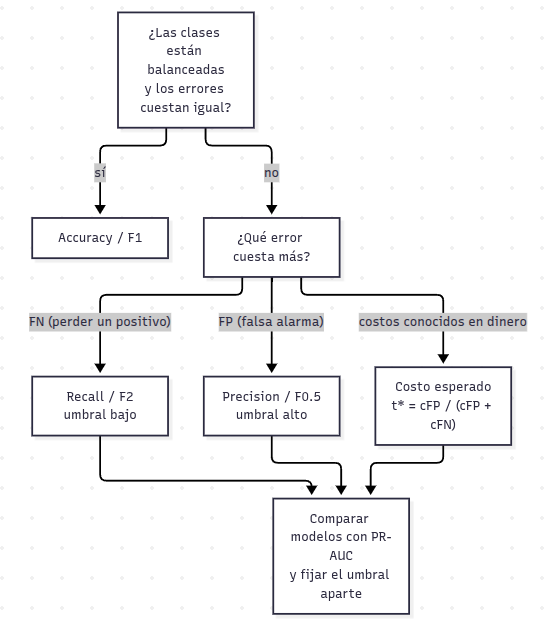

**Regla de higiene:** el umbral es un **hiperparámetro de decisión**: se elige con datos de **validación** y se **reporta** en el conjunto de **prueba** (nunca se optimiza sobre la prueba; la razón se desarrolla en el [cuaderno 02](02_Validacion_Cruzada_y_GridSearch.ipynb)). Lo ilustramos con el fraude: $c_{FN} = 200$ (monto medio no recuperado) y $c_{FP} = 5$ (fricción con el cliente), por lo que $t^\ = 5/205 \approx 0.024$.

In [ ]:
# ============================================================
# 7. Umbral por costo esperado: validacion para elegir, prueba para reportar
# ============================================================
C_FP, C_FN = 5.0, 200.0
t_teorico = C_FP / (C_FP + C_FN)

# Tres particiones: entrenamiento (ajusta el modelo), validacion (elige el umbral), prueba (reporta)
X_a, Xf_te2, y_a, yf_te2 = train_test_split(Xf, yf, test_size=0.3, stratify=yf, random_state=SEED)
Xf_tr2, Xf_va, yf_tr2, yf_va = train_test_split(X_a, y_a, test_size=0.3, stratify=y_a, random_state=SEED)
reg2 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(Xf_tr2, yf_tr2)
s_va, s_te = reg2.predict_proba(Xf_va)[:, 1], reg2.predict_proba(Xf_te2)[:, 1]

def costo(y, s, t):
    vp, fp, fn, vn = conteos(y, (s >= t).astype(int))
    return C_FP * fp + C_FN * fn

ts = np.linspace(0.001, 0.999, 999)
costos_va = np.array([costo(yf_va, s_va, t) for t in ts])
t_emp = ts[int(np.argmin(costos_va))]                                   # umbral elegido en VALIDACION
t_f1_va = ts[int(np.argmax([metricas_binarias(yf_va, (s_va >= t).astype(int))["F1"] for t in ts]))]

filas = {}
for nombre, t in [("Umbral por defecto (0.5)", 0.5), (f"Umbral que maximiza F1 (t={t_f1_va:.2f})", t_f1_va),
                  (f"Umbral de costo mínimo en validación (t={t_emp:.3f})", t_emp), (f"Umbral teórico (t*={t_teorico:.3f})", t_teorico)]:
    m = metricas_binarias(yf_te2, (s_te >= t).astype(int))
    filas[nombre] = {"costo en prueba": costo(yf_te2, s_te, t), "FN": m["FN"], "FP": m["FP"], "precision": m["precision"], "recall": m["recall"], "F1": m["F1"]}
tabla = pd.DataFrame(filas).T
display(tabla.round(3))
assert tabla.iloc[2]["costo en prueba"] < tabla.iloc[0]["costo en prueba"]            # optimizar el costo gana al umbral por defecto
print(f"t* teórico = {t_teorico:.3f} vs. t óptimo empírico en validación = {t_emp:.3f}: del mismo orden de magnitud y ambos muy por debajo de 0.5; la diferencia viene de que las probabilidades no están perfectamente calibradas y de la variabilidad muestral.")

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(ts, costos_va, color="#7c3aed", lw=2, label="Costo total en validación")
ax.axvline(0.5, color="gray", linestyle=":", label="Umbral por defecto 0.5")
ax.axvline(t_emp, color="#16a34a", linestyle="--", label=f"Mínimo empírico ($t$={t_emp:.3f})")
ax.axvline(t_teorico, color="#dc2626", linestyle="--", label=f"Teórico $t^*$={t_teorico:.3f}")
ax.set_xscale("log"); ax.set_xlabel("Umbral de decisión $t$ (escala log)"); ax.set_ylabel("Costo total ($c_{FP}\\,FP + c_{FN}\\,FN$)")
ax.set_title("El umbral de costo mínimo está muy por debajo de 0.5", fontweight="bold"); ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f"En prueba, pasar de t = 0.5 a t ≈ {t_emp:.3f} baja el costo de {tabla.iloc[0]['costo en prueba']:.0f} a {tabla.iloc[2]['costo en prueba']:.0f}, "
      "aceptando más falsas alarmas a cambio de atrapar más fraudes.")

---
## 8. `classification_report` y Buenas Prácticas de Interpretación 📋

`sklearn.metrics.classification_report` resume en una tabla la *precision*, el *recall*, el F1 y el **soporte** de cada clase, más tres filas de promedios (*accuracy*/*micro avg*, *macro avg* y *weighted avg*). Es **exactamente** lo que construimos en las secciones anteriores; lo reproducimos a mano para fijar ideas.

### Trampas frecuentes al interpretar

1. **Reportar solo *accuracy*** con clases desbalanceadas (Sección 2).
2. **Comparar modelos con un umbral fijo en 0.5**: un modelo puede verse peor solo porque su score está mal *calibrado*, no porque ordene peor. Compara con ROC-AUC/PR-AUC y **luego** elige el umbral.
3. **Optimizar el umbral en la prueba**: contamina la estimación (Sección 7 y [cuaderno 02](02_Validacion_Cruzada_y_GridSearch.ipynb)).
4. **Ignorar el soporte**: un F1 de 0.9 sobre 5 ejemplos no vale lo mismo que sobre 5 000; la incertidumbre importa.
5. **Mezclar convenciones**: ¿cuál es la clase positiva? ¿filas = real o predicho? ¿promedio *macro* o *weighted*? Documenta siempre estas elecciones.
6. **Olvidar la incertidumbre de la estimación**: una métrica en una única partición es una **estimación ruidosa**; la validación cruzada (cuaderno 02) cuantifica esa variabilidad.
7. **Métricas sin contexto de negocio**: un F1 de 0.8 no dice nada sin los costos de FP y FN (Sección 7).

In [ ]:
# ============================================================
# 8. classification_report reproducido desde cero y comparado con scikit-learn
# ============================================================
def reporte_desde_cero(y, y_pred, K):
    C = matriz_confusion(y, y_pred, K); M = metricas_multiclase(C)
    filas = {str(k): M["por_clase"].iloc[k].to_dict() for k in range(K)}
    filas["macro avg"] = dict(zip(["precision", "recall", "F1"], M["macro"]), soporte=C.sum())
    filas["weighted avg"] = dict(zip(["precision", "recall", "F1"], M["weighted"]), soporte=C.sum())
    return pd.DataFrame(filas).T, M["accuracy"]

y_cancer_hat = modelo.predict(Xc_te)
mio_rep, acc_rep = reporte_desde_cero(yc_te, y_cancer_hat, 2)
sk_rep = skm.classification_report(yc_te, y_cancer_hat, output_dict=True, zero_division=0)
for fila in ["0", "1", "macro avg", "weighted avg"]:
    for mio_col, sk_col in [("precision", "precision"), ("recall", "recall"), ("F1", "f1-score"), ("soporte", "support")]:
        assert np.isclose(mio_rep.loc[fila, mio_col], sk_rep[fila][sk_col]), (fila, mio_col)
assert np.isclose(acc_rep, sk_rep["accuracy"])
print("Reporte propio == classification_report (por clase, macro avg y weighted avg).\n")
display(mio_rep.round(3))
print(skm.classification_report(yc_te, y_cancer_hat, target_names=["benigno (0)", "maligno (1)"], digits=3))

# Los mismos numeros para el fraude: el reporte revela lo que el accuracy oculta
print("Fraude (umbral 0.5):")
print(skm.classification_report(yf_te, reg.predict(Xf_te), target_names=["legítima", "fraude"], digits=3))

---
## Resumen y Puntos Clave 🎯

| Concepto | Mensaje Central |
|---|---|
| **Matriz de confusión** | Los cuatro conteos (VP, FP, FN, VN) generan **todas** las métricas; cuidado con la convención de ejes en `scikit-learn` (`[[VN, FP], [FN, VP]]`) |
| **Accuracy** | $\frac{VP+VN}{n}$; con prevalencia $\pi$ pequeña un modelo trivial obtiene $1-\pi$: la **paradoja de la exactitud** |
| **Alternativas** | Accuracy balanceada y MCC (no engañan al trivial); métricas por clase |
| **Precision / Recall** | Pureza de las alarmas vs. cobertura de los positivos; **se compensan** al mover el umbral $t$ |
| **F1 y $F_\beta$** | Media **armónica** (castiga el desequilibrio; $\min\le F_1\le$ geométrica $\le$ aritmética); $\beta>1$ prioriza recall, $\beta<1$ precision; ignora los VN |
| **Multiclase** | *Macro* (clases por igual), *weighted* (por soporte), *micro* (= accuracy en una sola etiqueta) |
| **ROC-AUC / PR-AUC** | Independientes del umbral; AUC = $P(s^+>s^-)$; con desbalance extremo **PR-AUC es más informativa** (línea base $=\pi$) |
| **Costo y umbral** | $t^\ =c_{FP}/(c_{FP}+c_{FN})$ para scores calibrados; el umbral se elige en **validación**, no en prueba |
| **Implementación** | Todas las métricas desde cero coinciden con `sklearn.metrics` (verificadas con `assert`) |

> 🎓 **Siguiente paso:** [Métricas de Regresión](01_Metricas_de_Regresion.ipynb): cuando la respuesta es continua, ¿cómo medimos «cuánto nos equivocamos»?

---
### 🧠 Autoevaluación

1. Un modelo de detección de fraude tiene 99.2 % de *accuracy* sobre un conjunto con 1 % de fraudes. ¿Es un buen modelo? ¿Qué **tres** números pedirías (y por qué) para decidirlo?
2. Demuestra que $F_1 = \dfrac{2\,VP}{2\,VP + FP + FN}$ a partir de la media armónica de *precision* y *recall*. ¿Por qué esta forma deja claro que los verdaderos negativos no influyen?
3. Un cribado de una enfermedad grave tiene $c_{FN} = 50\,c_{FP}$. ¿Qué umbral teórico recomiendas para una probabilidad calibrada? ¿Qué métrica $F_\beta$ usarías para comparar candidatos y por qué?
4. En un problema multiclase de una sola etiqueta, ¿por qué $F_{1,\text{micro}} = \text{accuracy}$? ¿Cuándo preferirías el promedio *macro* y cuándo el *weighted*?

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Asignatura: Machine Learning</i>
  </p>
</div>